In [9]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = r"C:\Users\dariu\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1\insurance.csv"

df = pd.read_csv(path)
print(df)


      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


      age  sex     bmi  children  smoker      charges  region_northeast  \
0      19    0  27.900         0       1  16884.92400             False   
1      18    1  33.770         1       0   1725.55230             False   
2      28    1  33.000         3       0   4449.46200             False   
3      33    1  22.705         0       0  21984.47061             False   
4      32    1  28.880         0       0   3866.85520             False   
...   ...  ...     ...       ...     ...          ...               ...   
1333   50    1  30.970         3       0  10600.54830             False   
1334   18    0  31.920         0       0   2205.98080              True   
1335   18    0  36.850         0       0   1629.83350             False   
1336   21    0  25.800         0       0   2007.94500             False   
1337   61    0  29.070         0       1  29141.36030             False   

      region_northwest  region_southeast  region_southwest  
0                False             Fal

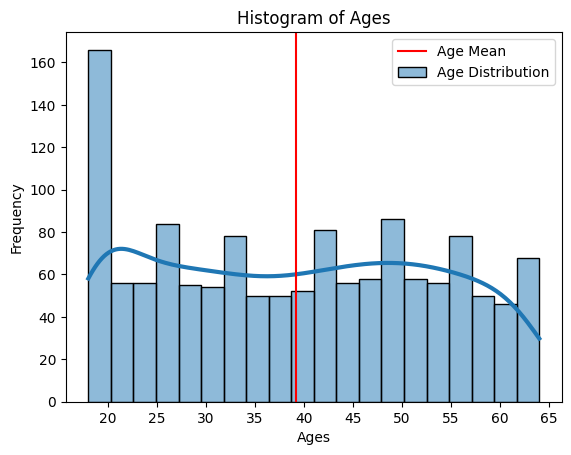

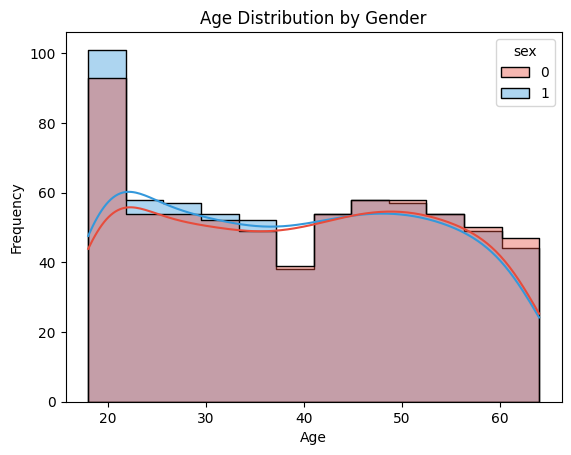

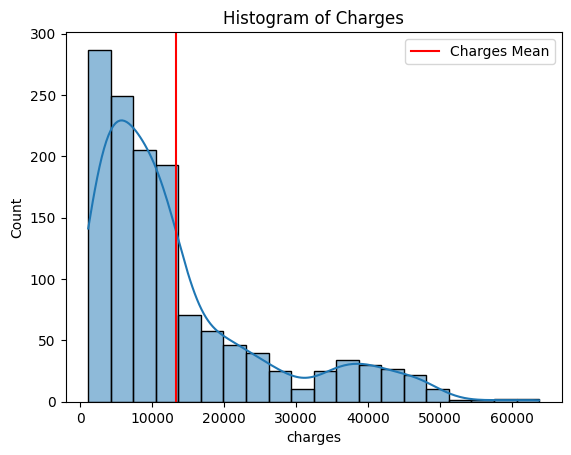

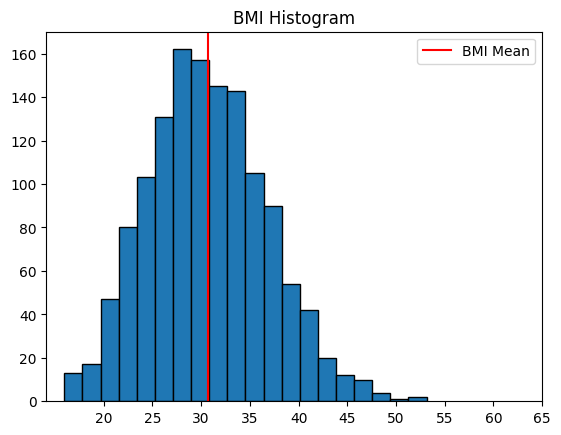

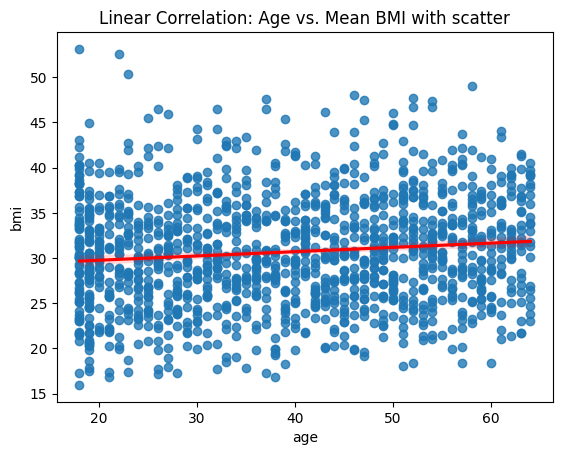

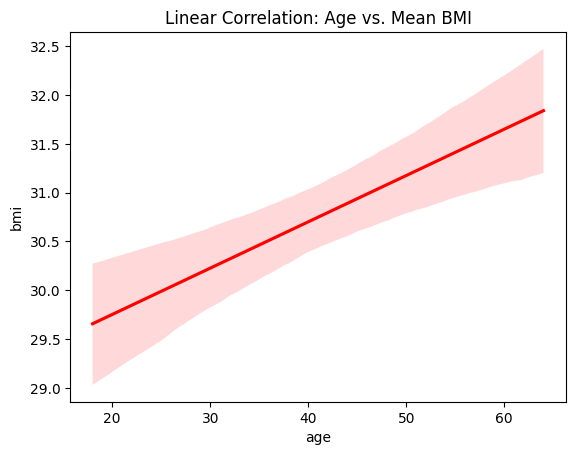

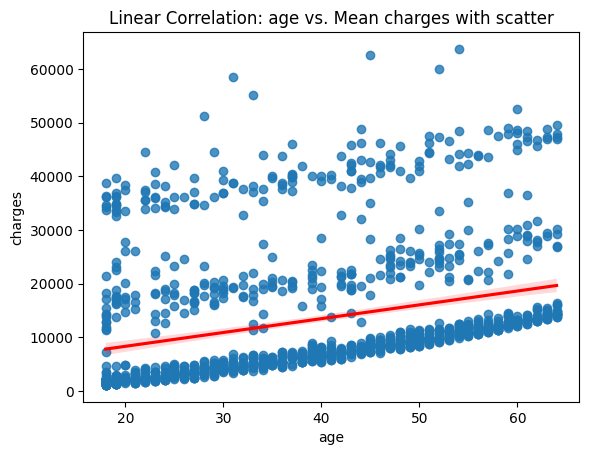

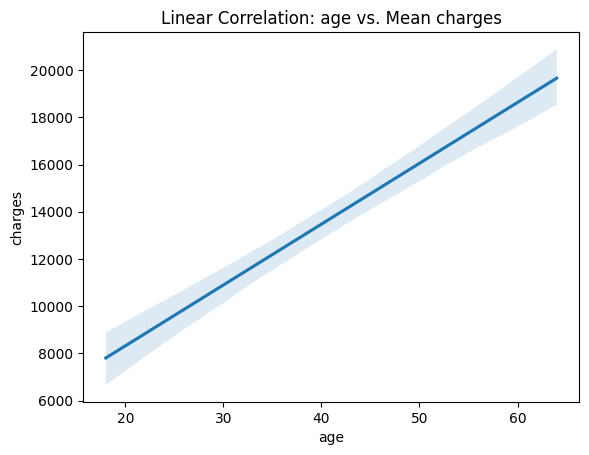

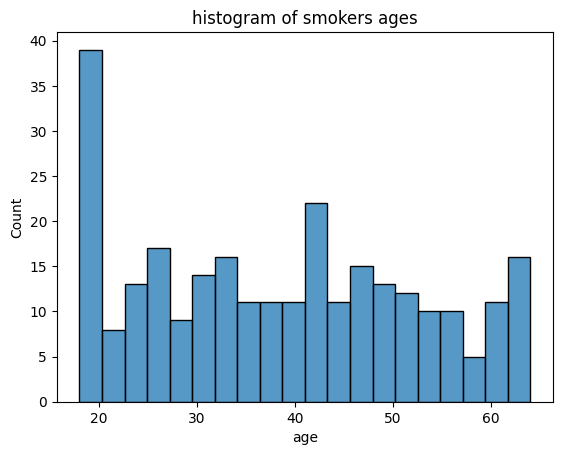

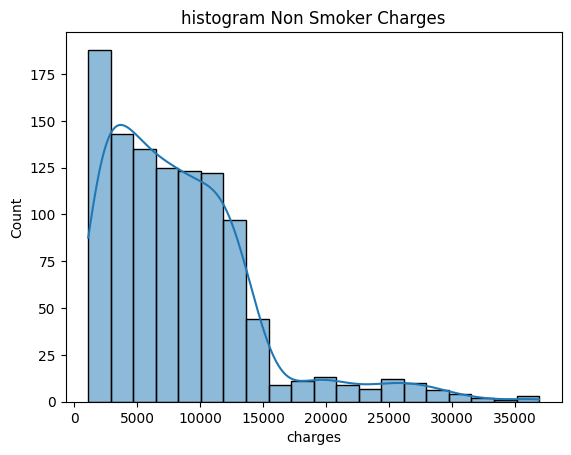

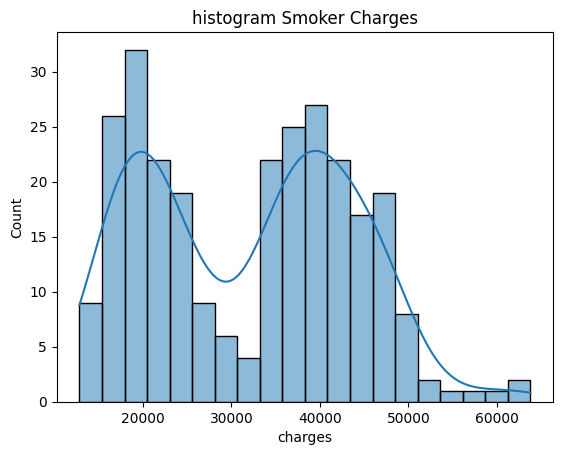

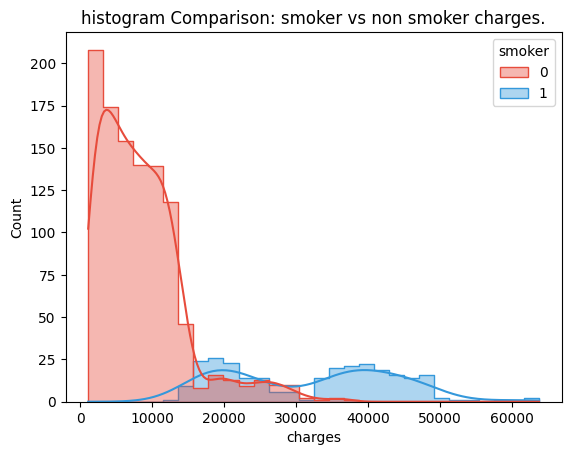

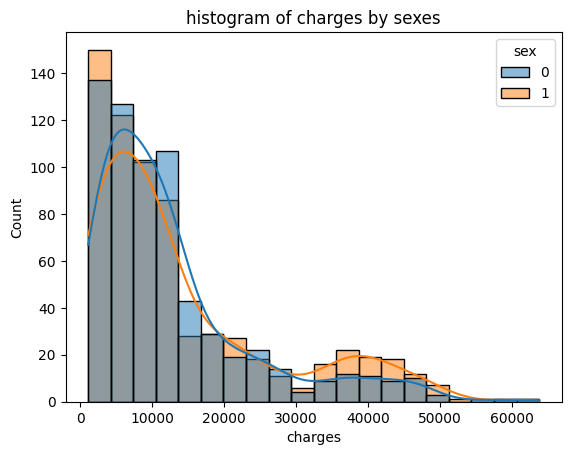

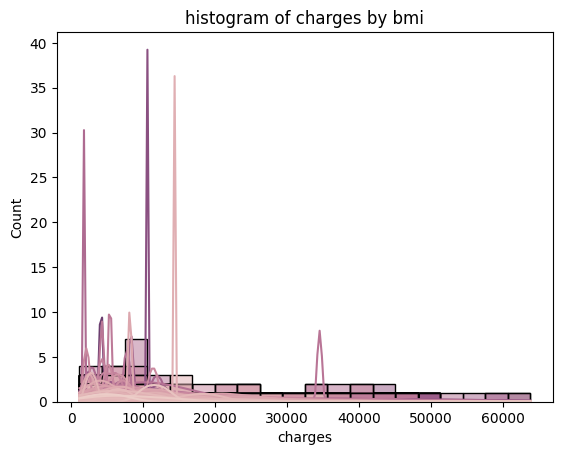

In [10]:

df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], prefix='region')
print(df)
print("corr")
print(df.corr(numeric_only=True))

# bar chart of sexes and smokers
counts = df['sex'].value_counts()
print(counts)
print(counts.head().values)
print(counts.head().name)

counts2 = df["smoker"].value_counts()
print(counts2)


plt.figure()
plt.grid(False)
ageMean= df["age"].mean()
sns.histplot(data=df, x="age", bins=20, edgecolor="black", kde=True,line_kws={"color": "purple", "linewidth": 3},label="Age Distribution")
plt.xticks(range(20,66,5))
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.axvline(x=ageMean, color="red",label="Age Mean")
plt.legend()
plt.title("Histogram of Ages")


plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", hue="sex",edgecolor = "black", kde=True, palette={1: "#3498db", 0: "#e74c3c"}, alpha=0.4, element="step")
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.grid(False)
sns.histplot(data = df, x = "charges", bins = 20, edgecolor = "black", kde = True)
chargeMean = np.mean(df["charges"])
plt.axvline(x=chargeMean, color="red",label="Charges Mean")
plt.legend()
plt.title("Histogram of Charges")

plt.figure()
plt.grid(False)
bmiMean= df["bmi"].mean()
plt.hist(df["bmi"],bins = 20,edgecolor="black")
plt.xticks(range(20,66,5))
plt.title("BMI Histogram")
plt.axvline(x=bmiMean, color="red",label="BMI Mean")
plt.legend()

plt.figure()
sns.regplot(data=df, x='age', y='bmi', line_kws={"color": "red"})
plt.title('Linear Correlation: Age vs. Mean BMI with scatter')

plt.figure()
sns.regplot(data=df, x='age', y='bmi', line_kws={"color": "red"},scatter = False)
plt.title('Linear Correlation: Age vs. Mean BMI')


plt.figure()
sns.regplot(data=df, x='age', y='charges',line_kws={"color": "red"},)
plt.title('Linear Correlation: age vs. Mean charges with scatter')

plt.figure()
sns.regplot(data=df, x='age', y='charges',scatter = False)
plt.title('Linear Correlation: age vs. Mean charges')

plt.figure()
sns.histplot(data = df.query("smoker == 1"), x = "age", bins = 20, edgecolor="black")
plt.title("histogram of smokers ages")

plt.figure()
sns.histplot(data=df.query("smoker == 0"), x="charges", bins=20, edgecolor="black", kde=True)
plt.title("histogram Non Smoker Charges")

plt.figure()
sns.histplot(data=df.query("smoker == 1"), x="charges", bins=20, edgecolor="black", kde=True)
plt.title("histogram Smoker Charges")

plt.figure()
sns.histplot(data=df, x="charges", hue="smoker", kde=True, palette={1: "#3498db", 0: "#e74c3c"}, alpha=0.4, element="step")
plt.title('histogram Comparison: smoker vs non smoker charges.')

plt.figure()
sns.histplot(data = df, x= "charges", hue= "sex", bins=20, edgecolor="black", kde=True,)
plt.title("histogram of charges by sexes")


plt.figure()
sns.histplot(data = df, x = "charges", hue= "bmi", bins=20, edgecolor="black", kde=True,legend = False)
plt.title("histogram of charges by bmi")
plt.show()


0.7214008260577199
32458.52589230331
8603.22107564026


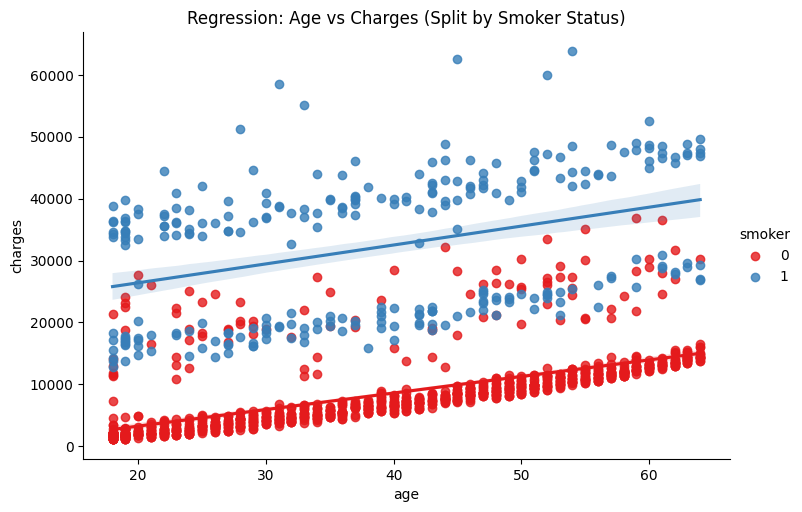

<Figure size 640x480 with 0 Axes>

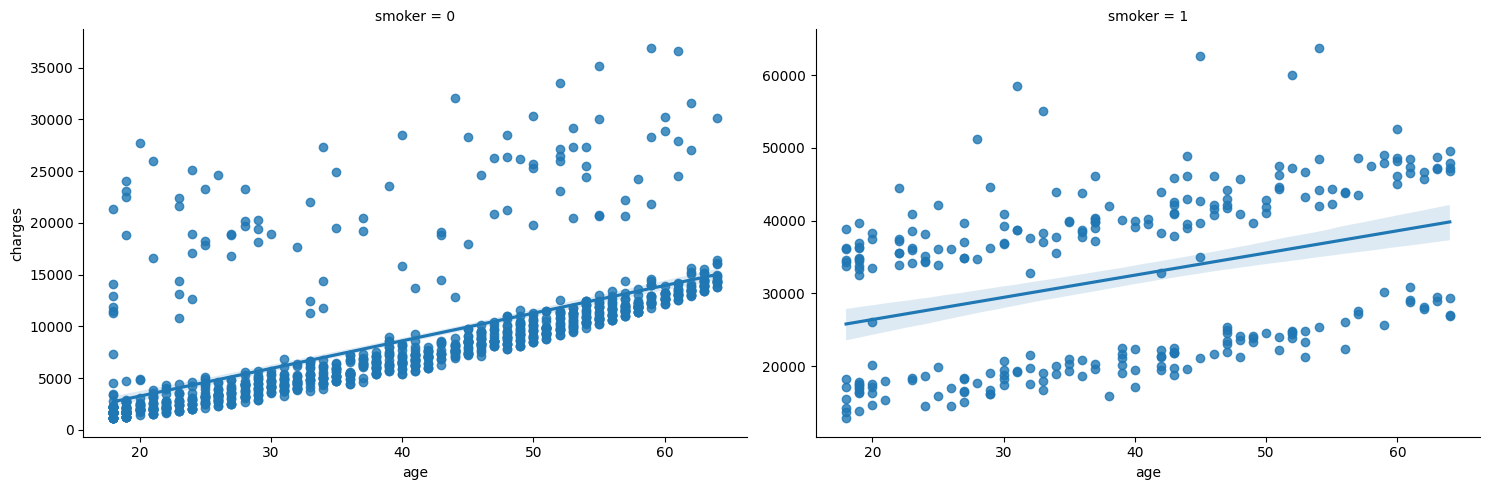

In [11]:
from sklearn.linear_model import LinearRegression

X = df[['age', 'smoker']]
y = df['charges']

model = LinearRegression()
model.fit(X, y)

R2_1= model.score(X, y)
print(R2_1)

testData1 = pd.DataFrame([[40, 1],[40,0]], columns=['age', 'smoker'])
test1 = model.predict(testData1)
print(test1[0])
print(test1[1])


sns.lmplot(data=df, x="age", y="charges", hue="smoker", palette="Set1", aspect=1.5)
plt.title("Regression: Age vs Charges (Split by Smoker Status)")

plt.figure()
sns.lmplot(data=df, x="age", y="charges", col="smoker", palette="Set1", aspect=1.5,facet_kws={'sharey': False})
plt.show()


In [12]:
x = X = df[['age', 'smoker','sex','bmi',]]
y = df['charges']

model2 = model = LinearRegression()
model.fit(X, y)

R2_2 = model.score(X, y)
print(R2_2)
testData = pd.DataFrame([[40, 1, 1, 30],[40,0,1,30]], columns=['age', 'smoker', 'sex', 'bmi'])
test = model.predict(testData)
print(test[0])
print(test[1])
#,['40','0','1','30']

0.7474972680928911
32160.993369084717
8327.1233306164


2 barchart smokers and non smokers

3 male and female bar chart

 4 region barchart

5 bmi distribution overall